# MeshFL Dataset

**Author:** Mohamed Masoud

This notebook inspects the Mindboggle subset used in MeshFL and documents:

- where the dataset is stored
- database structure
- how MRI volumes and labels are encoded
- example visualization of one sample and its associated ground-truth label



####  **Clone MeshFL Repo**

In [1]:
!git clone https://github.com/Mmasoud1/MeshFL.git
%cd MeshFL

Cloning into 'MeshFL'...
remote: Enumerating objects: 810, done.
remote: Counting objects: 100% (107/107), done.
remote: Compressing objects: 100% (73/73), done.
remote: Total 810 (delta 54), reused 74 (delta 31), pack-reused 703 (from 1)
Receiving objects: 100% (810/810), 6.25 MiB | 25.60 MiB/s, done.
Resolving deltas: 100% (410/410), done.
Filtering content: 100% (3/3), 440.32 MiB | 25.40 MiB/s, done.
/content/MeshFL


####  **Set mindboggle.db path**

MeshFL stores site-specific dataset  under:

- `test_data/site-1/mindboggle.db`
- `test_data/site-2/mindboggle.db`

This mirrors the decentralized setting,  each site accesses its own local data.

In [2]:
import sqlite3
import pandas as pd
from pathlib import Path

db_path = Path("/content/MeshFL/test_data/site-1/mindboggle.db")
conn = sqlite3.connect(str(db_path))
cursor = conn.cursor()

cursor.execute("SELECT name FROM sqlite_master WHERE type='table' ORDER BY name;")
tables = [row[0] for row in cursor.fetchall()]
print("Tables:", tables)

schema_rows = []

for table in tables:
    cursor.execute(f"PRAGMA table_info({table});")
    cols = cursor.fetchall()
    for col in cols:
        schema_rows.append({
            "table": table,
            "column_name": col[1],
            "type": col[2]
        })

schema_df = pd.DataFrame(schema_rows)
display(schema_df)


Tables: ['mindboggle101']


,table,column_name,type
0,mindboggle101,ID,INTEGER
1,mindboggle101,Image,BLOB
2,mindboggle101,Label,BLOB
3,mindboggle101,GWlabels,BLOB
4,mindboggle101,ANAlabels,BLOB


#### **Read a sample from the Dataset**

In [3]:
import zlib
import numpy as np
import matplotlib.pyplot as plt

cursor.execute("SELECT ID, Image, GWlabels FROM mindboggle101 LIMIT 1;")
sample_id, image_blob, label_blob = cursor.fetchone()

image = np.frombuffer(zlib.decompress(image_blob), dtype=np.float32).reshape((256, 256, 256))
label = np.frombuffer(zlib.decompress(label_blob), dtype=np.float32).reshape((256, 256, 256))

print("Sample ID:", sample_id)
print("Compressed image bytes:", len(image_blob))
print("Compressed label bytes:", len(label_blob))

print("Image shape:", image.shape)
print("Label shape:", label.shape)
print("Image dtype:", image.dtype)
print("Label dtype:", label.dtype)

print("Image min/max:", image.min(), image.max())
print("Label unique values:", np.unique(label))

Sample ID: 1
Compressed image bytes: 8278853
Compressed label bytes: 305591
Image shape: (256, 256, 256)
Label shape: (256, 256, 256)
Image dtype: float32
Label dtype: float32
Image min/max: 0.0 1.0
Label unique values: [0.  0.5 1. ]


#### **Visualize middle slice of MRI and GT**

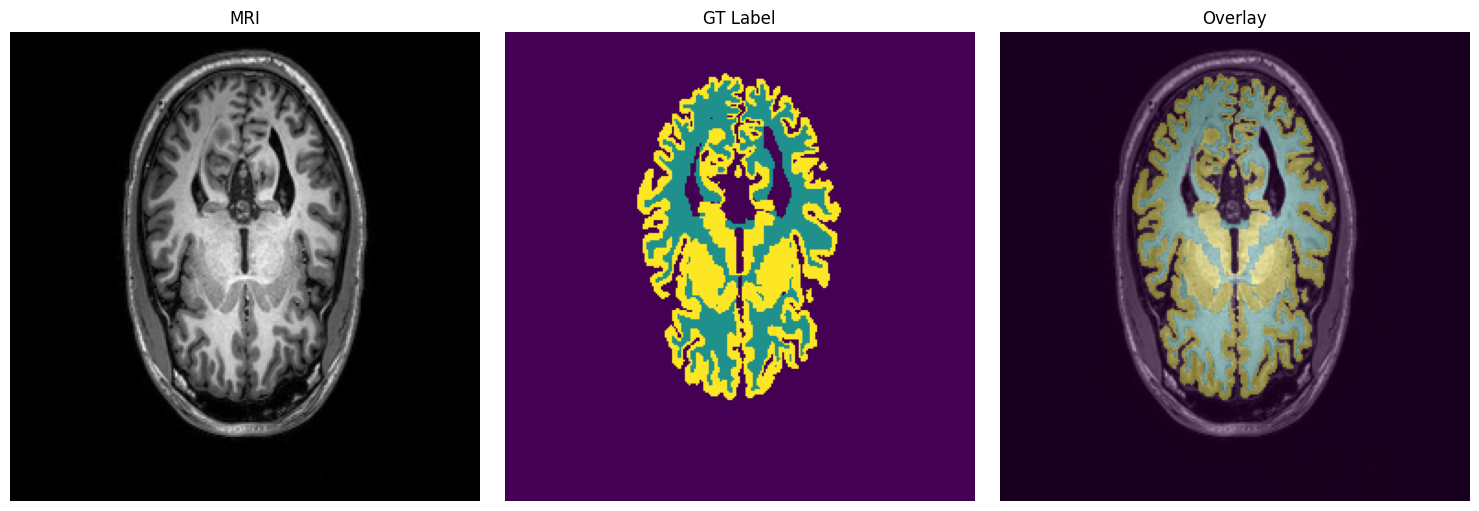

Saved figure: /content/MeshFL/Examples/dataset_read/figures/dataset_sample_overlay.png


In [4]:
from pathlib import Path

out_dir = Path("/content/MeshFL/Examples/dataset_read/figures")  # also fix "Examples" → "examples"
out_dir.mkdir(parents=True, exist_ok=True)

mid_idx = image.shape[2] // 2

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(image[:, :, mid_idx].T, cmap="gray", origin="lower")
axes[0].set_title("MRI")
axes[0].axis("off")

axes[1].imshow(label[:, :, mid_idx].T, origin="lower")
axes[1].set_title("GT Label")
axes[1].axis("off")

axes[2].imshow(image[:, :, mid_idx].T, cmap="gray", origin="lower")
axes[2].imshow(label[:, :, mid_idx].T, alpha=0.35, origin="lower")
axes[2].set_title("Overlay")
axes[2].axis("off")

plt.tight_layout()
save_path = out_dir / "dataset_sample_overlay.png"
plt.savefig(save_path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved figure:", save_path)

### **Summary**


- MeshFL uses a SQLite database (`mindboggle.db`) for dataset access
- the dataset is site-specific in decentralized training
- MRI volumes and labels are stored as compressed BLOBs
- labels are available directly from the database for training and evaluation

This design makes the dataset portable, reproducible, and easy to integrate into the MeshFL training pipeline.